# Pandas quick start
Pandas is a 3rd-party, open source, library used to for data science. It is perhaps the most important library for you, as a student of analytics.

At a high level, Pandas provides the following functionality:
1. Reading and writing data in various formats: csv, sql, feather and many others
2. A set of data structures in which to store data (so higher level than lists, tuples and dictionaries)
3. Functions to transform data in _many_ ways: individual columns, operating on multiple columns at once, aggregating in total or in by categories (aka group by), visualizing datasets, etc.

Further, _upstream_ libraries, such as ones providing machine learning algorithms (scikit-learn) know how to consume Pandas data structures.

Extremely helpful Pandas cheatsheet: https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf (search the web, there are many more, just as useful)

In [1]:
#!pip install seaborn

In [2]:
import numpy as np # <= numpy is only used once, for the np.log function (although pandas is built on top of it)
import pandas as pd # <= `pd` is almost always the abbreviation used for pandas

import seaborn as sns # <= seaborn is not part of pandas, but very useful charting library (built on top of matplotlib)
from bokeh.plotting import figure, show, output_file # <= another charting library, can be more interactive
from bokeh.io import output_notebook

In [3]:
# remember, since we will be drawing some charts, we need to execute this line - because seaborn uses matplotlib
%matplotlib inline 

# the following line tells pandas to avoid scietific notation
pd.set_option('display.float_format', '{:.2f}'.format)

# bokeh code to make it work in jupyter notebooks
output_notebook()

Loading BokehJS ...

In [4]:
%reload_ext postcell
%postcell register

PostCell loaded
Loading config file from /Users/victorji/Documents/GitHub/lectures/postcell.conf
Registered user Victor_Ji at https://postcell.io/post_cell


## Quick walk-through of Pandas

### Load file and take a quick look at it

Note that this file is available at: https://www.kaggle.com/kumarajarshi/life-expectancy-who/home
Go to that URL, click 'Download' which will start downloading a zip file. Load it as shown below:

In [5]:
# Read csv file
life_df = pd.read_csv("../../datasets/life-expectancy/life-expectancy-who.zip2", compression='zip')

In [6]:
type(life_df)

pandas.core.frame.DataFrame

In [7]:
life_df.head() # Look at the first 5 lines to visually inspect data

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.00,263.00,62,0.01,71.28,65.00,1154,...,6.00,8.16,65.00,0.10,584.26,33736494.00,17.20,17.30,0.48,10.10
1,Afghanistan,2014,Developing,59.90,271.00,64,0.01,73.52,62.00,492,...,58.00,8.18,62.00,0.10,612.70,327582.00,17.50,17.50,0.48,10.00
2,Afghanistan,2013,Developing,59.90,268.00,66,0.01,73.22,64.00,430,...,62.00,8.13,64.00,0.10,631.74,31731688.00,17.70,17.70,0.47,9.90
3,Afghanistan,2012,Developing,59.50,272.00,69,0.01,78.18,67.00,2787,...,67.00,8.52,67.00,0.10,669.96,3696958.00,17.90,18.00,0.46,9.80
4,Afghanistan,2011,Developing,59.20,275.00,71,0.01,7.10,68.00,3013,...,68.00,7.87,68.00,0.10,63.54,2978599.00,18.20,18.20,0.45,9.50


In [8]:
life_df.shape # This file has 2,938 records (rows) and 22 columns

(2938, 22)

In [9]:
life_df.columns # List of columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [10]:
#life_df.columns = [c.strip() for c in life_df.columns]

In [11]:
#life_df.columns

**WARNING** Notice that some columns have an extra space!

In [12]:
life_df.dtypes

Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

In [13]:
life_df.describe() # quick summary of all the columns

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.00,2928.00,2928.00,2938.00,2744.00,2938.00,2385.00,2938.00,2904.00,2938.00,2919.00,2712.00,2919.00,2938.00,2490.00,2286.00,2904.00,2904.00,2771.00,2775.00
mean,2007.52,69.22,164.80,30.30,4.60,738.25,80.94,2419.59,38.32,42.04,82.55,5.94,82.32,1.74,7483.16,12753375.12,4.84,4.87,0.63,11.99
std,4.61,9.52,124.29,117.93,4.05,1987.91,25.07,11467.27,20.04,160.45,23.43,2.50,23.72,5.08,14270.17,61012096.51,4.42,4.51,0.21,3.36
min,2000.00,36.30,1.00,0.00,0.01,0.00,1.00,0.00,1.00,0.00,3.00,0.37,2.00,0.10,1.68,34.00,0.10,0.10,0.00,0.00
25%,2004.00,63.10,74.00,0.00,0.88,4.69,77.00,0.00,19.30,0.00,78.00,4.26,78.00,0.10,463.94,195793.25,1.60,1.50,0.49,10.10
50%,2008.00,72.10,144.00,3.00,3.75,64.91,92.00,17.00,43.50,4.00,93.00,5.75,93.00,0.10,1766.95,1386542.00,3.30,3.30,0.68,12.30
75%,2012.00,75.70,228.00,22.00,7.70,441.53,97.00,360.25,56.20,28.00,97.00,7.49,97.00,0.80,5910.81,7420359.00,7.20,7.20,0.78,14.30
max,2015.00,89.00,723.00,1800.00,17.87,19479.91,99.00,212183.00,87.30,2500.00,99.00,17.60,99.00,50.60,119172.74,1293859294.00,27.70,28.60,0.95,20.70


In [14]:
life_df.describe().T # Flip or `transpose` the data for easier viewing

,count,mean,std,min,25%,50%,75%,max
Year,2938.00,2007.52,4.61,2000.00,2004.00,2008.00,2012.00,2015.00
Life expectancy,2928.00,69.22,9.52,36.30,63.10,72.10,75.70,89.00
Adult Mortality,2928.00,164.80,124.29,1.00,74.00,144.00,228.00,723.00
infant deaths,2938.00,30.30,117.93,0.00,0.00,3.00,22.00,1800.00
Alcohol,2744.00,4.60,4.05,0.01,0.88,3.75,7.70,17.87
percentage expenditure,2938.00,738.25,1987.91,0.00,4.69,64.91,441.53,19479.91
Hepatitis B,2385.00,80.94,25.07,1.00,77.00,92.00,97.00,99.00
Measles,2938.00,2419.59,11467.27,0.00,0.00,17.00,360.25,212183.00
BMI,2904.00,38.32,20.04,1.00,19.30,43.50,56.20,87.30
under-five deaths,2938.00,42.04,160.45,0.00,0.00,4.00,28.00,2500.00


### Visualize data

In [15]:
sns.__version__

'0.13.2'

CPU times: user 9.56 s, sys: 101 ms, total: 9.66 s
Wall time: 9.68 s


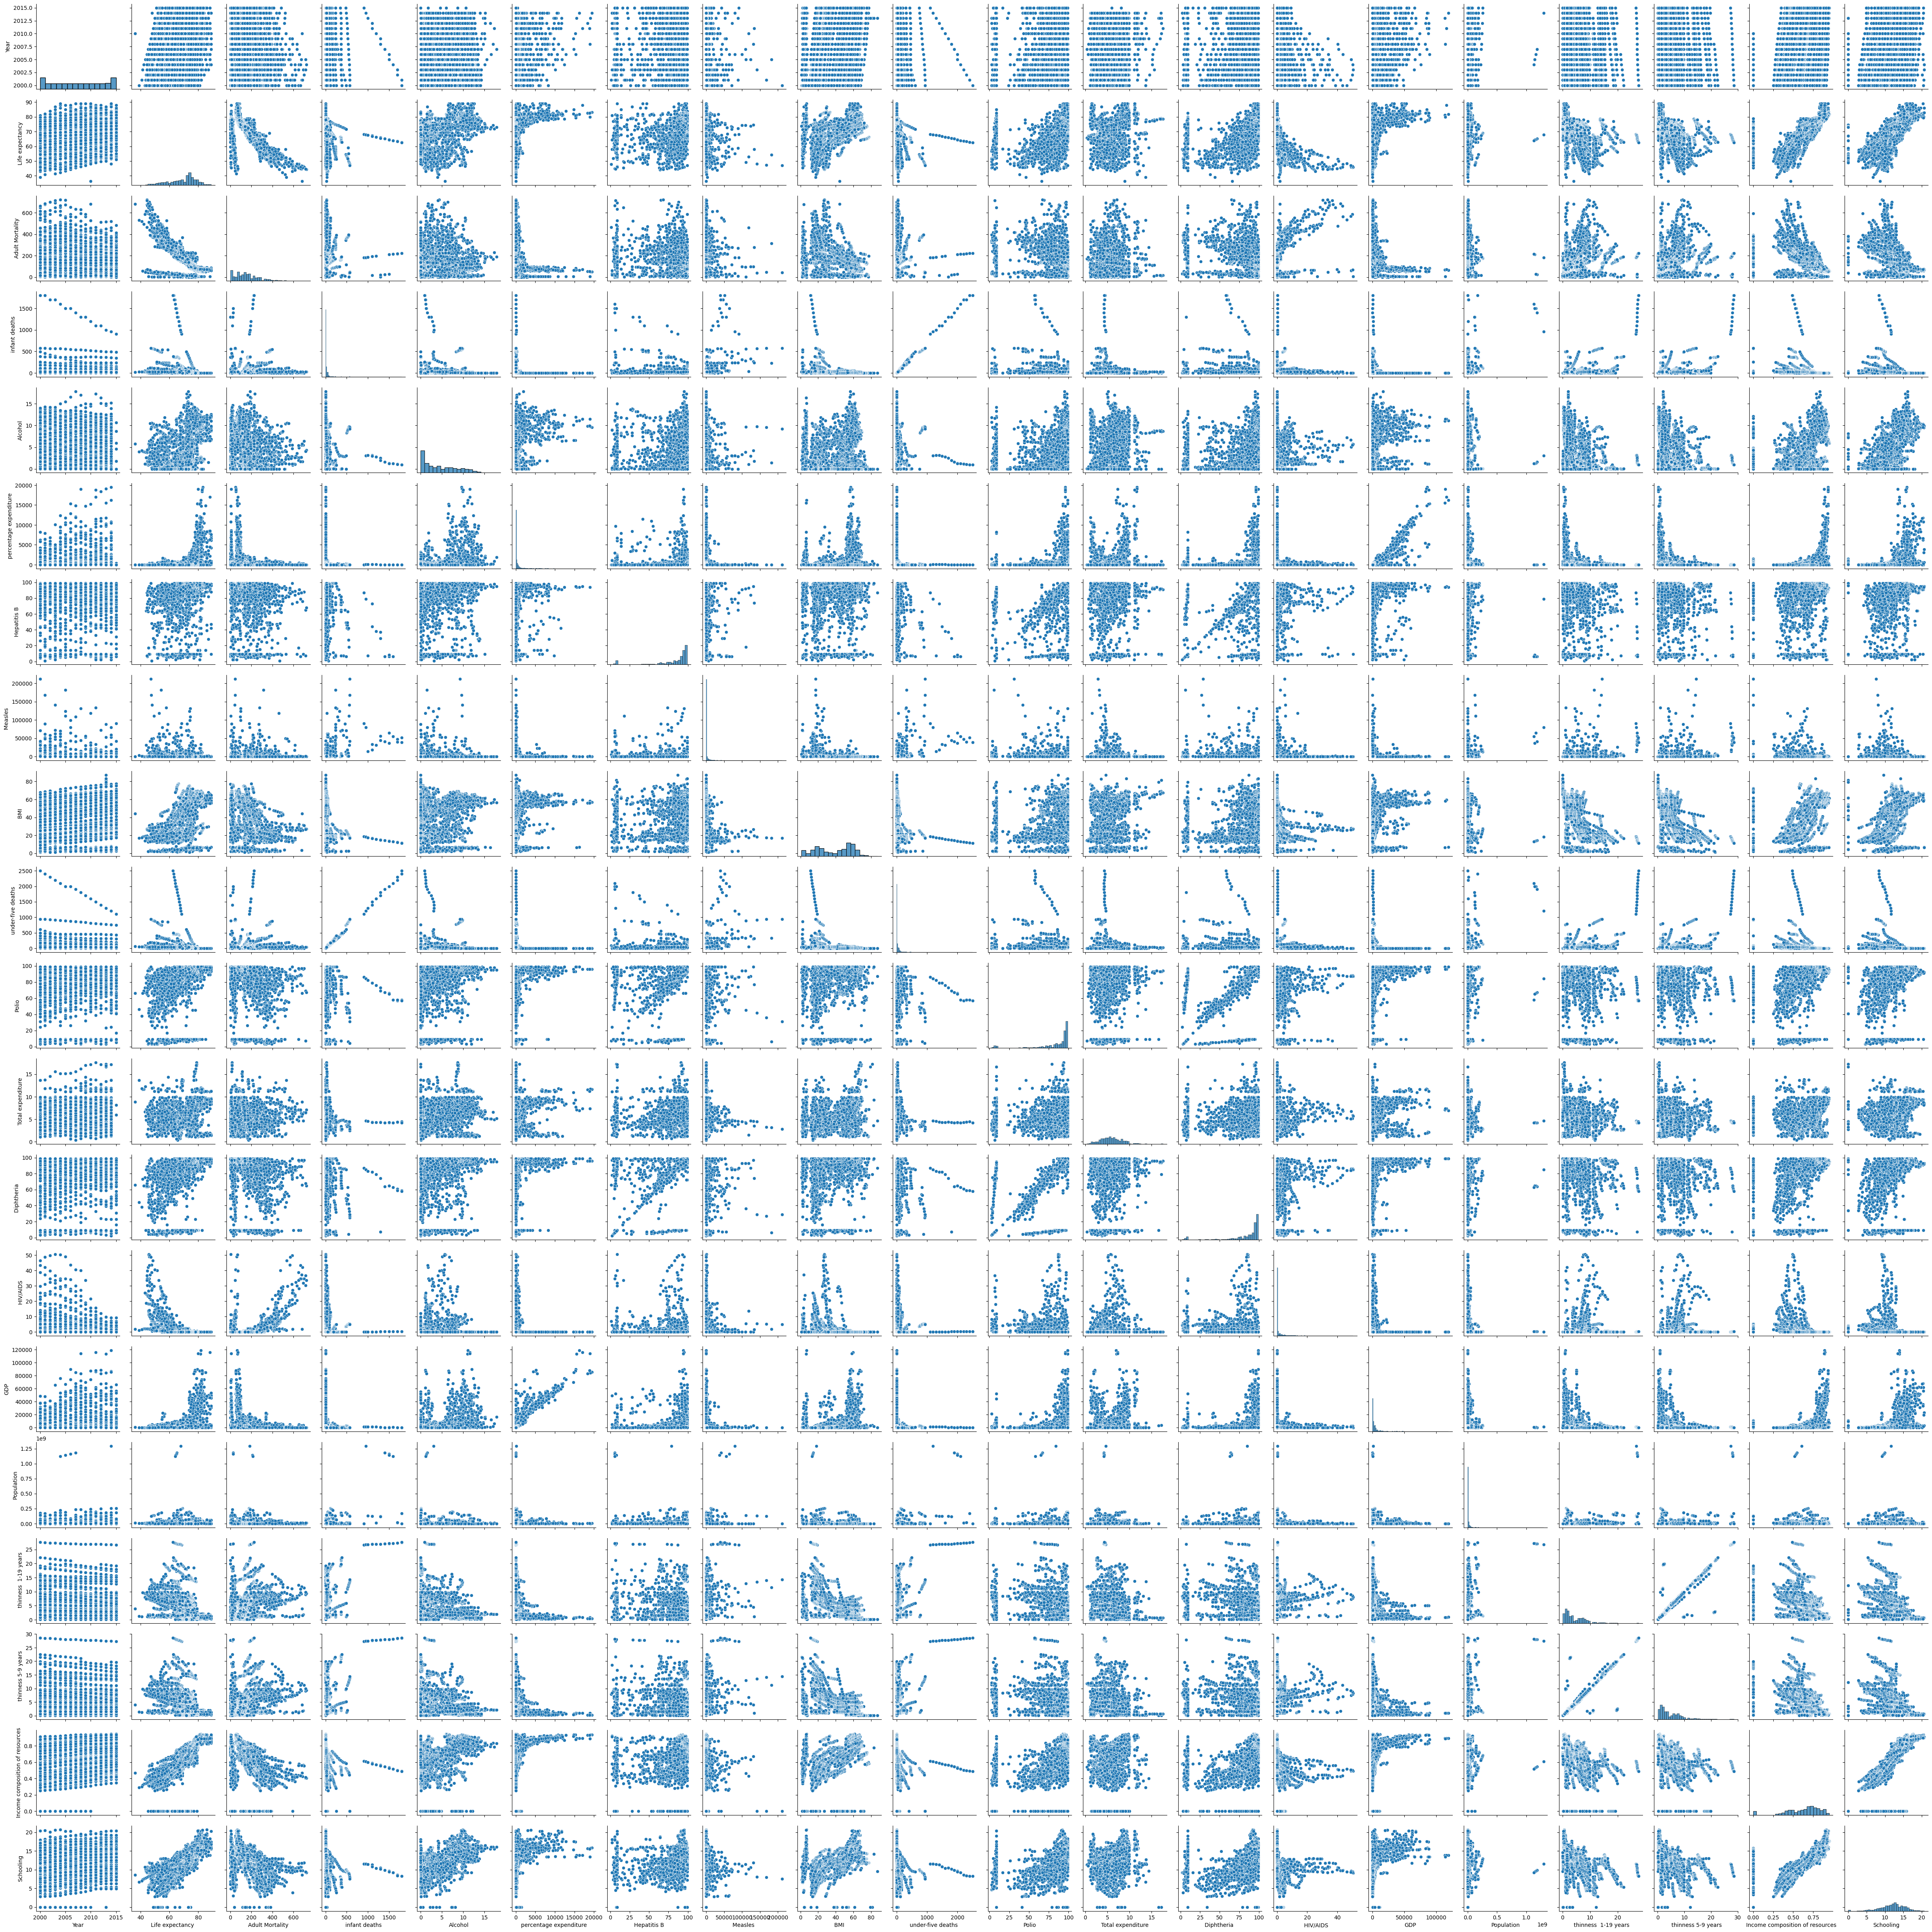

In [16]:
# Warning, this step may take a minute or two to complete
%time sns.pairplot(life_df) # look at all variables at once - pair-plot

The previous plot isn't very useful because there are too many columns. What if we had fewer columns? Let's just select the first few columns:

In [17]:
first_few_df = life_df[['Country', 'Year', 'Population', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ']]
first_few_df.head()

,Country,Year,Population,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles
0,Afghanistan,2015,33736494.00,65.00,263.00,62,0.01,71.28,65.00,1154
1,Afghanistan,2014,327582.00,59.90,271.00,64,0.01,73.52,62.00,492
2,Afghanistan,2013,31731688.00,59.90,268.00,66,0.01,73.22,64.00,430
3,Afghanistan,2012,3696958.00,59.50,272.00,69,0.01,78.18,67.00,2787
4,Afghanistan,2011,2978599.00,59.20,275.00,71,0.01,7.10,68.00,3013


In [18]:
first_few_df.shape

(2938, 10)

### Selecting columns

Given dataframe `df`, you select columns by passing it a list of columns:

```python
list_of_cols = ['col1', 'col2', 'col3']
df[list_of_cols]
```

or

```python
df[['col1', 'col2', 'col3']] # <= notice two square brackets!
```

**Exercise** Pick columns 'Country', 'Year' and 'Population' from dataframe 'life_df'

In [19]:
%%postcell exercise_030_a

#type your answer here

Cell posted for evaluation


Let's also limit the data to the year 2015

In [20]:
first_few_2015_df = first_few_df[first_few_df.Year == 2015]
first_few_2015_df

,Country,Year,Population,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles
0,Afghanistan,2015,33736494.00,65.00,263.00,62,0.01,71.28,65.00,1154
16,Albania,2015,28873.00,77.80,74.00,0,4.60,364.98,99.00,0
32,Algeria,2015,39871528.00,75.60,19.00,21,NaN,0.00,95.00,63
48,Angola,2015,2785935.00,52.40,335.00,66,NaN,0.00,64.00,118
64,Antigua and Barbuda,2015,NaN,76.40,13.00,0,NaN,0.00,99.00,0
...,...,...,...,...,...,...,...,...,...,...
2858,Venezuela (Bolivarian Republic of),2015,NaN,74.10,157.00,9,NaN,0.00,87.00,0
2874,Viet Nam,2015,NaN,76.00,127.00,28,NaN,0.00,97.00,256
2890,Yemen,2015,NaN,65.70,224.00,37,NaN,0.00,69.00,468
2906,Zambia,2015,161587.00,61.80,33.00,27,NaN,0.00,9.00,9


In [21]:
first_few_2015_df.shape

(183, 10)

### Selecting rows
Given dataframe `df`, a criteria can be given as an expression which returns `True` for every row which should be selected

```python
mask = df.Year == 2015
df[mask]
```
or

```python
df[df.Year == 2015]
```

In [22]:
first_few_df.Year # aka first_few_df.['Year']

0       2015
1       2014
2       2013
3       2012
4       2011
        ... 
2933    2004
2934    2003
2935    2002
2936    2001
2937    2000
Name: Year, Length: 2938, dtype: int64

In [23]:
first_few_df.Year == 2015

0        True
1       False
2       False
3       False
4       False
        ...  
2933    False
2934    False
2935    False
2936    False
2937    False
Name: Year, Length: 2938, dtype: bool

**Exercise** Show rows in 'life_df' for Afghanistan

In [24]:
%%postcell exercise_030_b

#type your answer here

Cell posted for evaluation


CPU times: user 1.75 s, sys: 25.8 ms, total: 1.77 s
Wall time: 1.77 s


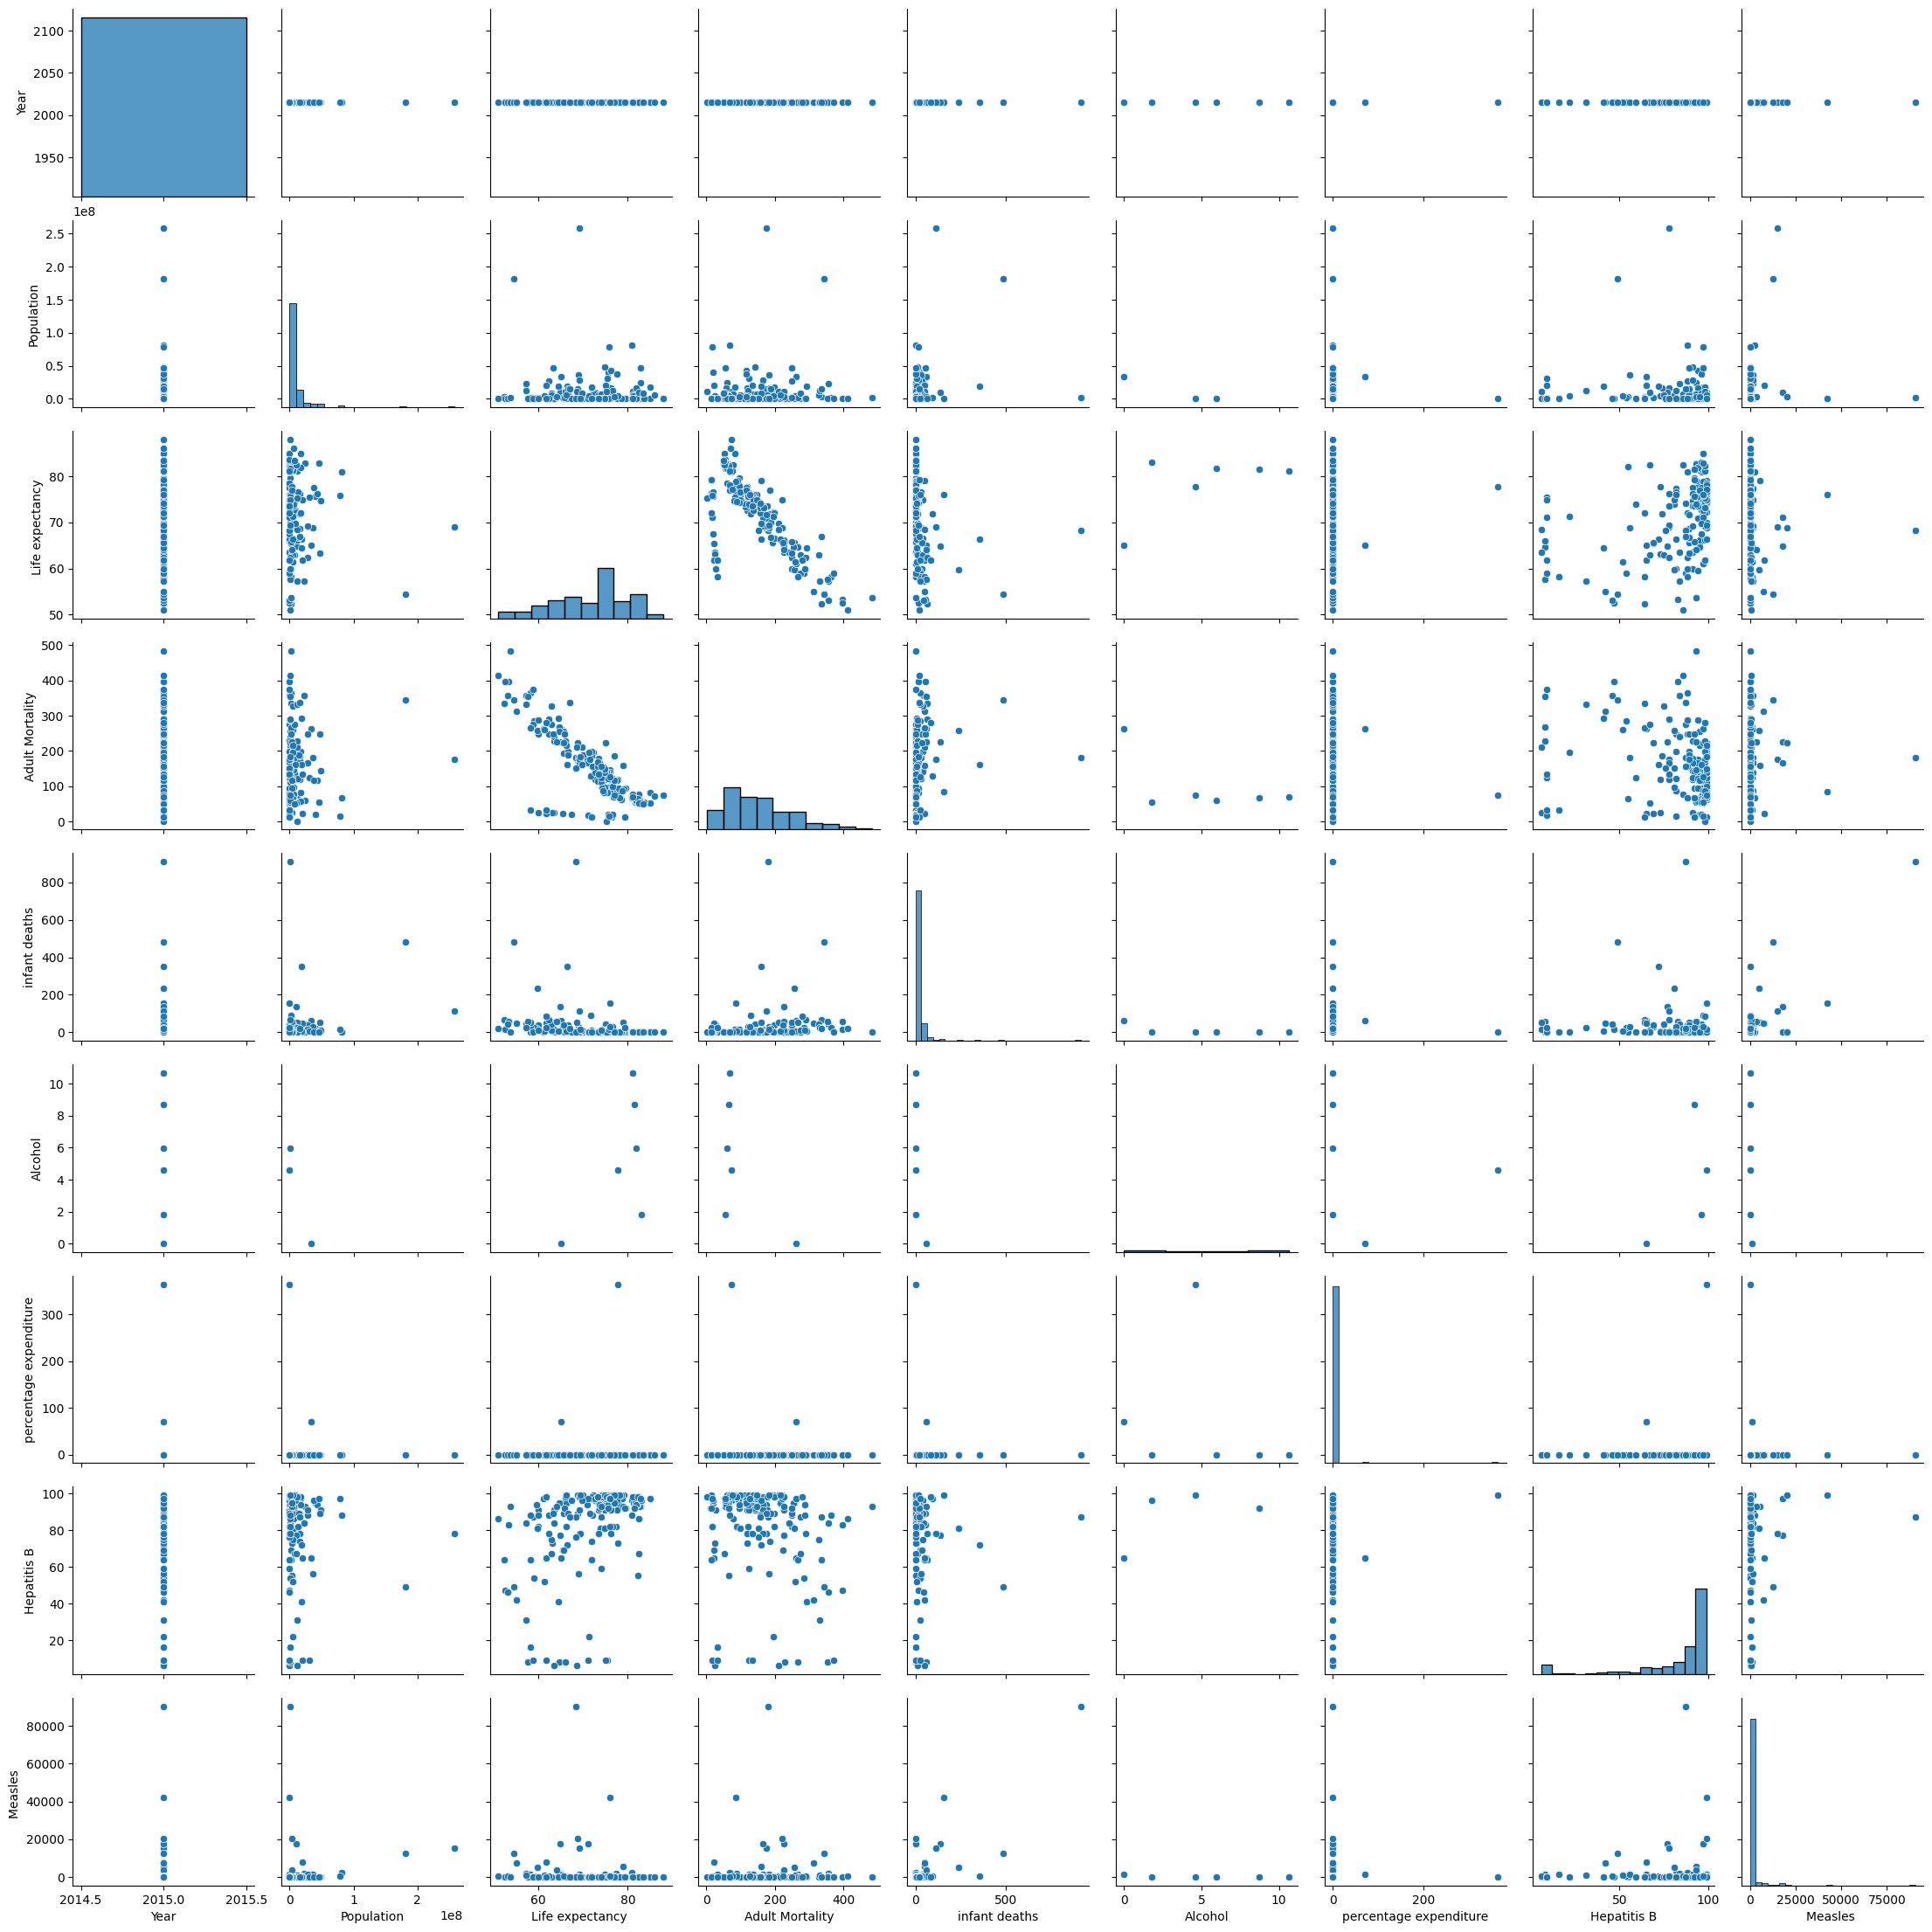

In [25]:
%time sns.pairplot(first_few_2015_df)

In [26]:
#first_few_2015_df['Population'] # Show the column 'Population'

In [27]:
#first_few_2015_df.columns

In [28]:
#first_few_2015_df['Life expectancy '] # <= Notice the extra space!

#### Modern Pandas suggest using `.loc[]` to select rows and columns

In [29]:
life_df.loc[life_df.Year == 2015, ['Country', 'Population']].shape

(183, 2)

#### Use `.query`, if you are comfortable with SQL

In [30]:
first_few_2015_df.query('Country == "Angola"')

,Country,Year,Population,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles
48,Angola,2015,2785935.00,52.40,335.00,66,NaN,0.00,64.00,118


In [31]:
first_few_2015_df.query(' Population < 30_000')

,Country,Year,Population,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles
16,Albania,2015,28873.00,77.80,74.00,0,4.60,364.98,99.00,0
1266,Israel,2015,8381.00,82.50,58.00,0,NaN,0.00,96.00,80
1378,Kiribati,2015,11247.00,66.30,198.00,0,NaN,0.00,82.00,0
1522,Lithuania,2015,29491.00,73.60,165.00,0,NaN,0.00,94.00,50
2441,Sri Lanka,2015,2966.00,74.90,138.00,3,NaN,0.00,99.00,1568
2633,Tonga,2015,16364.00,73.50,133.00,0,NaN,0.00,78.00,0
2649,Trinidad and Tobago,2015,13692.00,71.20,17.00,0,NaN,0.00,9.00,0
2842,Vanuatu,2015,26463.00,72.00,13.00,0,NaN,0.00,64.00,39


You can do math within a query expression

In [32]:
first_few_2015_df.query(' Population/100 < 300')

,Country,Year,Population,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles
16,Albania,2015,28873.00,77.80,74.00,0,4.60,364.98,99.00,0
1266,Israel,2015,8381.00,82.50,58.00,0,NaN,0.00,96.00,80
1378,Kiribati,2015,11247.00,66.30,198.00,0,NaN,0.00,82.00,0
1522,Lithuania,2015,29491.00,73.60,165.00,0,NaN,0.00,94.00,50
2441,Sri Lanka,2015,2966.00,74.90,138.00,3,NaN,0.00,99.00,1568
2633,Tonga,2015,16364.00,73.50,133.00,0,NaN,0.00,78.00,0
2649,Trinidad and Tobago,2015,13692.00,71.20,17.00,0,NaN,0.00,9.00,0
2842,Vanuatu,2015,26463.00,72.00,13.00,0,NaN,0.00,64.00,39


You can use logical connectives: `and`, `or`, `not`

In [33]:
first_few_2015_df.query(' Population < 30000 and Alcohol > 0')

,Country,Year,Population,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles
16,Albania,2015,28873.00,77.80,74.00,0,4.60,364.98,99.00,0


In [34]:
first_few_2015_df[(first_few_2015_df.Population < 30000) & (first_few_2015_df.Alcohol > 0)]

,Country,Year,Population,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles
16,Albania,2015,28873.00,77.80,74.00,0,4.60,364.98,99.00,0


You can use externally defined variables

In [35]:
pop_threshold = 30_000
first_few_2015_df.query(' Population < @pop_threshold')

,Country,Year,Population,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles
16,Albania,2015,28873.00,77.80,74.00,0,4.60,364.98,99.00,0
1266,Israel,2015,8381.00,82.50,58.00,0,NaN,0.00,96.00,80
1378,Kiribati,2015,11247.00,66.30,198.00,0,NaN,0.00,82.00,0
1522,Lithuania,2015,29491.00,73.60,165.00,0,NaN,0.00,94.00,50
2441,Sri Lanka,2015,2966.00,74.90,138.00,3,NaN,0.00,99.00,1568
2633,Tonga,2015,16364.00,73.50,133.00,0,NaN,0.00,78.00,0
2649,Trinidad and Tobago,2015,13692.00,71.20,17.00,0,NaN,0.00,9.00,0
2842,Vanuatu,2015,26463.00,72.00,13.00,0,NaN,0.00,64.00,39


If you column name has a space in it, you can 'quote' it using backticks (shift + tilda) on most keyboads

In [ ]:
first_few_2015_df.query(' `infant deaths` < 5')

,Country,Year,Population,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles
16,Albania,2015,28873.00,77.80,74.00,0,4.60,364.98,99.00,0
64,Antigua and Barbuda,2015,NaN,76.40,13.00,0,NaN,0.00,99.00,0
96,Armenia,2015,291695.00,74.80,118.00,1,NaN,0.00,94.00,33
112,Australia,2015,23789338.00,82.80,59.00,1,NaN,0.00,93.00,74
128,Austria,2015,8633169.00,81.50,65.00,0,NaN,0.00,93.00,309
...,...,...,...,...,...,...,...,...,...,...
2730,Ukraine,2015,4515429.00,71.30,195.00,4,NaN,0.00,22.00,105
2746,United Arab Emirates,2015,NaN,77.10,75.00,1,NaN,0.00,99.00,347
2762,United Kingdom of Great Britain and Northern I...,2015,NaN,81.20,69.00,3,10.66,0.00,NaN,91
2810,Uruguay,2015,3431552.00,77.00,116.00,0,NaN,0.00,95.00,0


Perhaps 'query' is slower than other methods?

In [37]:
%timeit life_df.query(' Population < 5')
%timeit life_df.query(' `Population` < 5')
%timeit life_df[life_df["Population"] < 5]
%timeit life_df.loc[life_df["Population"] < 5, :]

778 μs ± 16.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
775 μs ± 13.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
50.7 μs ± 3.85 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
56.4 μs ± 978 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### Visualize the relationship between 'Population' and 'Life expectancy '

<Axes: xlabel='Population', ylabel='Life expectancy '>

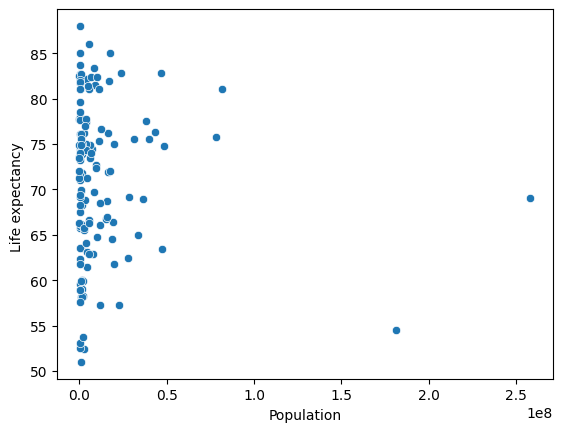

In [38]:
sns.scatterplot(x='Population', y='Life expectancy ', data=first_few_2015_df)

<Axes: xlabel='Population', ylabel='Life expectancy '>

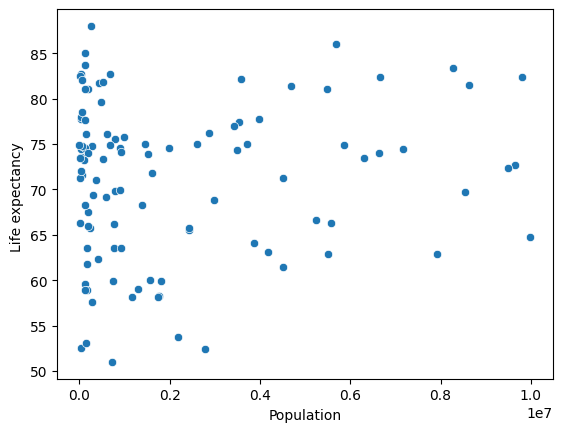

In [39]:
sns.scatterplot(x='Population', y='Life expectancy ', data=first_few_2015_df[first_few_2015_df.Population < 10_500_000])

In [40]:
#Bokeh code
TOOLTIPS = [('Country', '@Country', ), ('Population', '@Population', )]

p = figure(title = "Pop vs Life expectancy", tooltips=TOOLTIPS)

p.scatter('Population', 'Life expectancy ', source=first_few_2015_df,fill_alpha=0.2, size=10)
show(p)

In [41]:
first_few_2015_df['Life expectancy '].value_counts() # So what are common life expectancies?

Life expectancy 
75.00    4
63.50    3
74.90    3
65.70    3
81.10    3
        ..
64.80    1
77.60    1
79.00    1
73.90    1
67.00    1
Name: count, Length: 132, dtype: int64

<Axes: xlabel='Life expectancy ', ylabel='Count'>

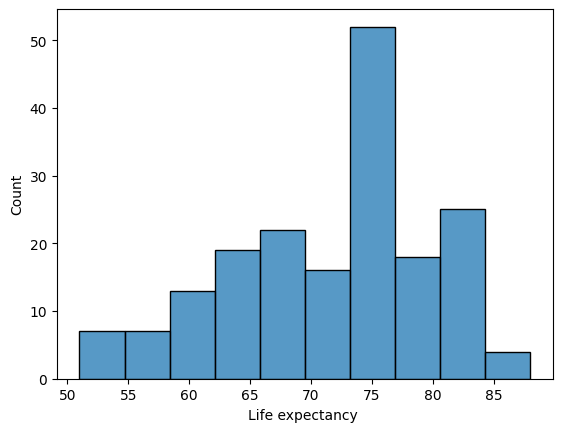

In [42]:
sns.histplot(first_few_2015_df['Life expectancy '])

In [43]:
min(first_few_2015_df['Life expectancy ']), max(first_few_2015_df['Life expectancy '])

(51.0, 88.0)

In [44]:
np.min(first_few_2015_df['Life expectancy ']), np.max(first_few_2015_df['Life expectancy '])

(np.float64(51.0), np.float64(88.0))

In [45]:
first_few_2015_df['Life expectancy '].min(), first_few_2015_df['Life expectancy '].max()

(np.float64(51.0), np.float64(88.0))

In [46]:
%timeit min(first_few_2015_df['Population']), max(first_few_2015_df['Population'])
%timeit np.min(first_few_2015_df['Population']), np.max(first_few_2015_df['Population'])
%timeit first_few_2015_df['Population'].min(), first_few_2015_df['Population'].max()

13.5 μs ± 141 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
16.4 μs ± 162 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
12.6 μs ± 113 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


Previous list of numbers is not very useful, let's plot the distribution:

<Axes: ylabel='Frequency'>

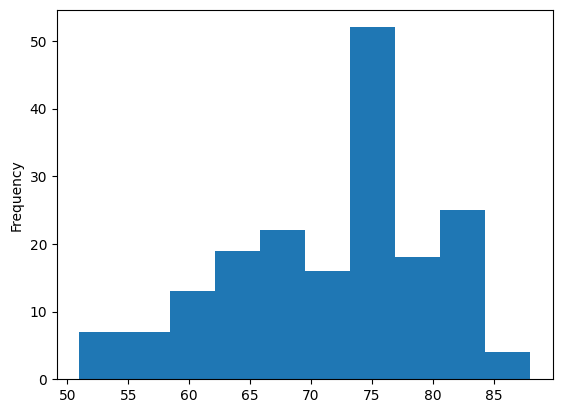

In [47]:
first_few_2015_df['Life expectancy '].plot.hist()

### Investigate infant deaths

<Axes: ylabel='Frequency'>

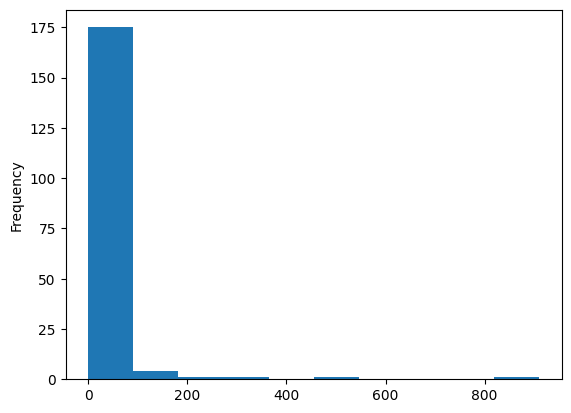

In [48]:
first_few_2015_df['infant deaths'].plot.hist()

<Axes: ylabel='Frequency'>

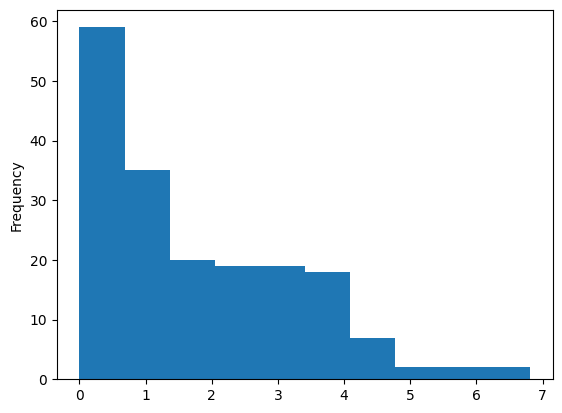

In [49]:
np.log(first_few_2015_df['infant deaths']+1).plot.hist() # just to "zoom" in quickly - dirty hack

<Axes: ylabel='Frequency'>

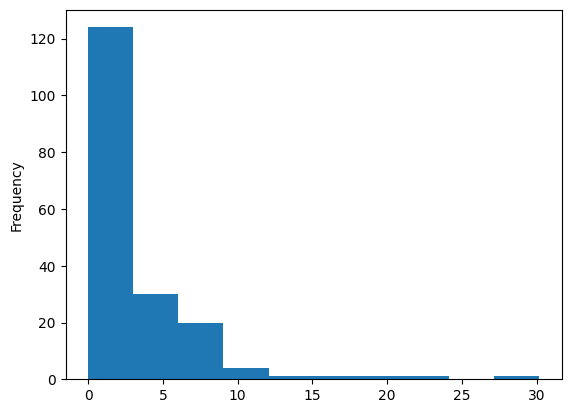

In [50]:
np.sqrt(first_few_2015_df['infant deaths']).plot.hist() # just to "zoom" in quickly - dirty hack

<Axes: ylabel='Frequency'>

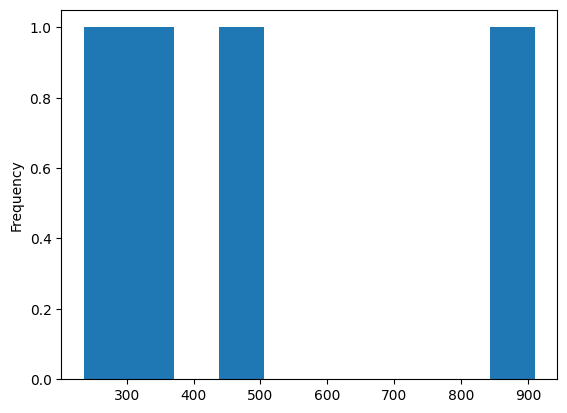

In [51]:
first_few_2015_df[first_few_2015_df['infant deaths'] > 200]['infant deaths'].plot.hist()

In [52]:
#There are some cases where infant deaths are over 200???
first_few_2015_df[first_few_2015_df['infant deaths'] > 200]

,Country,Year,Population,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles
721,Democratic Republic of the Congo,2015,NaN,59.80,258.00,236,NaN,0.00,81.00,5020
1186,India,2015,1395398.00,68.30,181.00,910,NaN,0.00,87.00,90387
1893,Nigeria,2015,181181744.00,54.50,344.00,483,NaN,0.00,49.00,12423
1942,Pakistan,2015,18938513.00,66.40,161.00,352,NaN,0.00,72.00,386


The numbers for infant deaths are _so_ high that we need to go back to the data source and double check our understanding.

**Exercise** Check the exact definition of 'infant deaths' at the website which houses the data:
https://www.kaggle.com/kumarajarshi/life-expectancy-who

(Number of Infant Deaths per 1000 population)

### Aggregates by country or year

One of the best ways to extract insight from a dataset is to compare aggregates across various dimensions

In [53]:
life_df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [54]:
life_df[["Year", "Life expectancy "]].groupby("Year").mean()

,Life expectancy
Year,
2000,66.75
2001,67.13
2002,67.35
2003,67.43
2004,67.65
2005,68.21
2006,68.67
2007,69.04
2008,69.43


<Axes: xlabel='Year'>

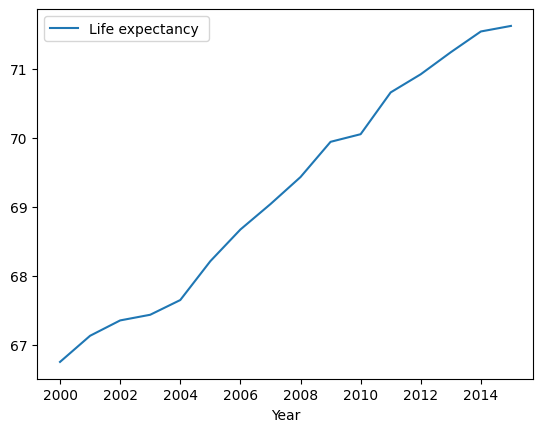

In [55]:
life_df[["Year", "Life expectancy "]].groupby("Year").mean().plot()

Although the `groupby` command is best used in SQL databases, Pandas implementation is quite robust

<Axes: xlabel='Year'>

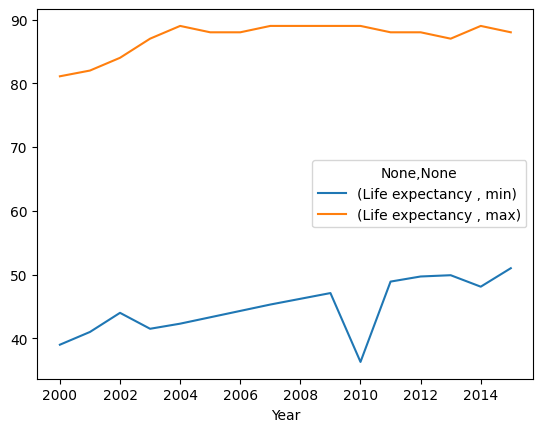

In [56]:
life_df[["Year", "Life expectancy "]].groupby("Year").aggregate(("min", "max")).plot()

#### Watch out for typographic issues

The 'Measles' value is defined as 'number of reported cases per 1,000 population.' Let's find the actual number of measles per country (in 2015):

In [57]:
(first_few_2015_df['Measles ']/1000) * first_few_2015_df['Population'] # What happened? (hint, extra space)
# Why did you get the error and have you seen that error before? 

0      38931914.08
16            0.00
32      2511906.26
48       328740.33
64             NaN
           ...    
2858           NaN
2874           NaN
2890           NaN
2906       1454.28
2922          0.00
Length: 183, dtype: float64

In [58]:
first_few_2015_df.columns

Index(['Country', 'Year', 'Population', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles '],
      dtype='object')

#### Add vectors as scalars

In [59]:
# In the calculation below, notice that we just added the two vectors, as if they were numbers...no loops!!
(first_few_2015_df['Measles ']/1000) * first_few_2015_df['Population']

0      38931914.08
16            0.00
32      2511906.26
48       328740.33
64             NaN
           ...    
2858           NaN
2874           NaN
2890           NaN
2906       1454.28
2922          0.00
Length: 183, dtype: float64

Something _very_ interesting happened above. We added two lists or vectors of numbers, without using a loop! Pandas and numpy (and matrix math) works this way.


#### Add new column

Let's add this column back to our data frame:

In [60]:
# We are creating a new column!
first_few_2015_df.loc[:, 'Total Measles'] = (first_few_2015_df['Measles ']/1000) * first_few_2015_df['Population']

/var/folders/wl/xx434fr13rs3bk0q76dx3mf00000gn/T/ipykernel_5176/473209224.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  first_few_2015_df.loc[:, 'Total Measles'] = (first_few_2015_df['Measles ']/1000) * first_few_2015_df['Population']


What's with that warning?
Turns out, `first_few_2015_df` is not the original dataframe. It is a subsetted view. If we update this subset, what happens to the remaining rows and columns? Better to modify the original dataframe.

In [61]:
first_few_2015_df.head()

,Country,Year,Population,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,Total Measles
0,Afghanistan,2015,33736494.00,65.00,263.00,62,0.01,71.28,65.00,1154,38931914.08
16,Albania,2015,28873.00,77.80,74.00,0,4.60,364.98,99.00,0,0.00
32,Algeria,2015,39871528.00,75.60,19.00,21,NaN,0.00,95.00,63,2511906.26
48,Angola,2015,2785935.00,52.40,335.00,66,NaN,0.00,64.00,118,328740.33
64,Antigua and Barbuda,2015,NaN,76.40,13.00,0,NaN,0.00,99.00,0,NaN


In [62]:
life_df.loc[:, 'Total Measles'] = (life_df['Measles ']/1000) * life_df['Population']

In [63]:
life_df['Total Measles'] = (life_df['Measles ']/1000) * life_df['Population']

In [64]:
life_df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Total Measles
0,Afghanistan,2015,Developing,65.00,263.00,62,0.01,71.28,65.00,1154,...,8.16,65.00,0.10,584.26,33736494.00,17.20,17.30,0.48,10.10,38931914.08
1,Afghanistan,2014,Developing,59.90,271.00,64,0.01,73.52,62.00,492,...,8.18,62.00,0.10,612.70,327582.00,17.50,17.50,0.48,10.00,161170.34
2,Afghanistan,2013,Developing,59.90,268.00,66,0.01,73.22,64.00,430,...,8.13,64.00,0.10,631.74,31731688.00,17.70,17.70,0.47,9.90,13644625.84
3,Afghanistan,2012,Developing,59.50,272.00,69,0.01,78.18,67.00,2787,...,8.52,67.00,0.10,669.96,3696958.00,17.90,18.00,0.46,9.80,10303421.95
4,Afghanistan,2011,Developing,59.20,275.00,71,0.01,7.10,68.00,3013,...,7.87,68.00,0.10,63.54,2978599.00,18.20,18.20,0.45,9.50,8974518.79


In [65]:
1

1